In [2]:
library(bridgesampling)
library(coda)
library(tictoc)
library(readr)
library(dplyr)
library(ggplot2)
library(ggsci)
library(patchwork)

Warning message:
"package 'dplyr' was built under R version 4.4.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'ggsci' was built under R version 4.4.3"
Warning message:
"package 'patchwork' was built under R version 4.4.3"


In [73]:
set.seed(42)

In [74]:
pima_data <- read_csv("pima_preprocessed.csv", show_col_types=FALSE)
X_pima_final <- as.matrix(pima_data[, -1])
y_pima <- pima_data[[1]]

cc_data <- read_csv("creditcard_preprocessed.csv", show_col_types=FALSE)
X_cc_final <- as.matrix(cc_data %>% select(-y, -Amount))
y_cc <- cc_data[[1]]

tcga_data <- read_csv("tcga_preprocessed.csv", show_col_types=FALSE)
X_tcga_final <- as.matrix(tcga_data[, -1])
y_tcga <- tcga_data[[1]]

In [75]:
# 贝叶斯后验
log_post <- function(beta, data){
    X <- data$X
    y <- data$y
    log_prior <- sum(dnorm(beta, mean=0, sd=sqrt(10), log=TRUE))
    eta <- as.numeric(X %*% beta)
    log_like <- sum(dbinom(y, size=1, prob=plogis(eta), log=TRUE))
    return(log_like + log_prior)
}

In [76]:
# 核心指标
bridge_pipeline <- function(X_data, y_data, samples_csv, dataset_name){
    samples_df <- read_csv(samples_csv, show_col_types = FALSE)
    p <- ncol(X_data)
    samples_matrix <- as.matrix(samples_df[, 1:p])
    colnames(samples_matrix) <- paste0("beta_", 1:p)
    
    # 采样质量ESS
    mcmc_obj <- as.mcmc(samples_matrix)
    mean_ess <- mean(effectiveSize(mcmc_obj))

    # 边界似然积分以及运行时间
    lb <- rep(-Inf, p); names(lb) <- colnames(samples_matrix)
    ub <- rep(Inf, p); names(ub) <- colnames(samples_matrix)

    tic()

    bridge_res <- bridge_sampler(
        samples = samples_matrix,
        log_posterior = log_post,
        data = list(X=X_data, y=y_data),
        lb = lb,
        ub = ub, 
        silent = TRUE
    )

    time_res <- toc(quiet = TRUE)
    runtime_secs <- time_res$toc - time_res$tic
    cat(sprintf("logZ: %.2f | ESS: %.1f | Runtime: %.2fs\n", 
              bridge_res$logml, mean_ess, runtime_secs))
    return(data.frame(
        Dataset = dataset_name,
        Algorithm = "Bridge",
        logZ = bridge_res$logml,
        ESS = mean_ess,
        Runtime = runtime_secs
    ))
}          

In [77]:
final_results <- data.frame()

res_pima <- bridge_pipeline(X_pima_final, y_pima, "pima_posterior_samples.csv", "Pima(Low)")
final_results <- rbind(final_results, res_pima)

res_cc <- bridge_pipeline(X_cc_final, y_cc, "creditcard_posterior_samples.csv", "CreditCard(Mid)")
final_results <- rbind(final_results, res_cc)

res_tcga <- bridge_pipeline(X_tcga_final, y_tcga, "tcga_posterior_samples.csv", "TCGA(High)")
final_results <- rbind(final_results, res_tcga)

logZ: -387.49 | ESS: 2116.1 | Runtime: 5.97s
logZ: -98.71 | ESS: 2962.2 | Runtime: 5.60s


Warning message:
"83 of the 7500 log_prob() evaluations on the proposal draws produced -Inf/Inf."


logZ: -72.31 | ESS: 1942.5 | Runtime: 13.47s


In [78]:
final_results$Dataset <- c("Pima\n(Low)", "CreditCard\n(Mid)", "TCGA\n(High)")
final_results$Dataset <- factor(final_results$Dataset, 
                                levels = c("Pima\n(Low)", "CreditCard\n(Mid)", "TCGA\n(High)"))
write.csv(final_results, "Bridge_results.csv", row.names=FALSE)
gradient_tones <- c("Pima\n(Low)" = "#A8DADC",      
                    "CreditCard\n(Mid)" = "#457B9D",
                    "TCGA\n(High)" = "#1D3557")    

In [79]:
my_theme <- function() {
  ggplot2::theme_minimal(base_size = 13, base_family = "sans") + 
    ggplot2::theme(
      panel.grid.major.x = ggplot2::element_blank(), 
      panel.grid.minor = ggplot2::element_blank(),
      panel.grid.major.y = ggplot2::element_line(color = "#E5E5E5", linetype = "dotted", linewidth = 0.8),
      axis.line.x = ggplot2::element_line(color = "#333333", linewidth = 1),
      axis.ticks.x = ggplot2::element_line(color = "#333333", linewidth = 1),
      axis.text.x = ggplot2::element_text(color = "#222222", size = 11, face = "bold", lineheight = 1.1),
      axis.text.y = ggplot2::element_text(color = "#555555", size = 11),
      axis.title = ggplot2::element_text(face = "bold", size = 12, color = "#222222"),
      plot.title = ggplot2::element_text(face = "bold", hjust = 0.5, size = 13, margin = ggplot2::margin(b = 12)),
      legend.position = "none",
      plot.margin = ggplot2::margin(t = 15, r = 35, b = 15, l = 35) 
    )
}

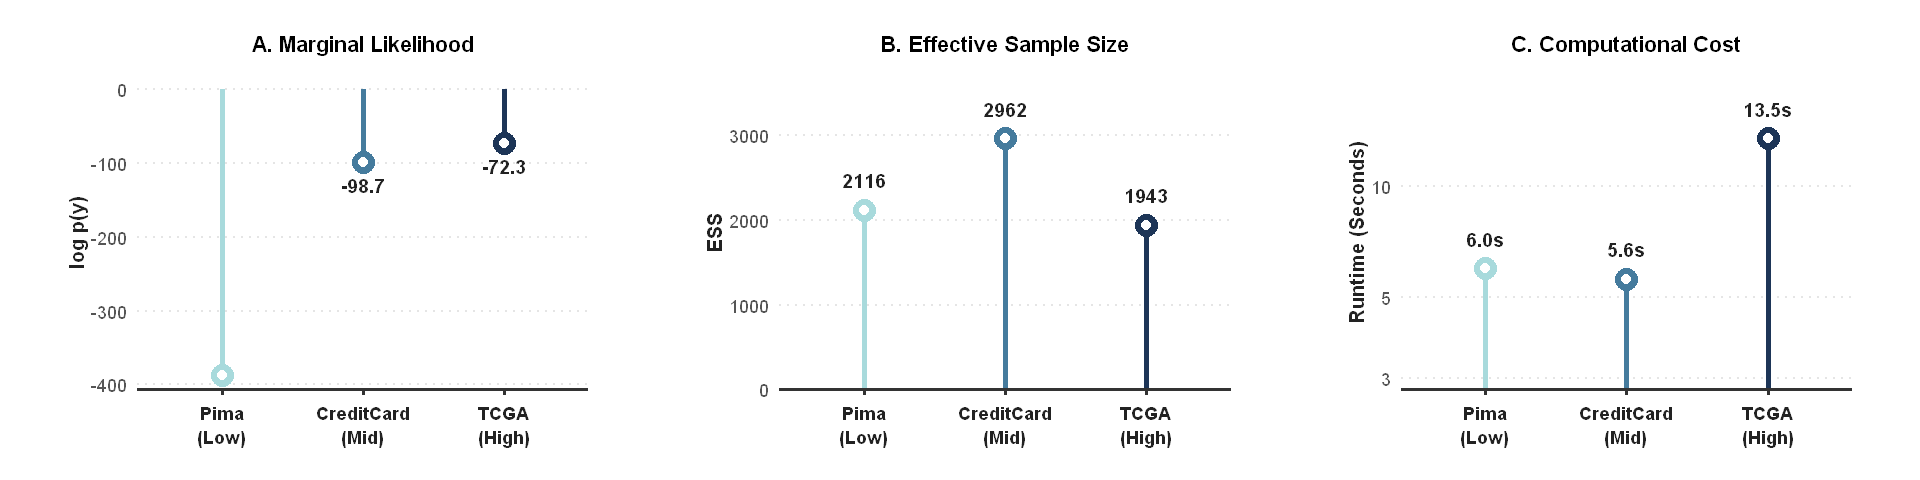

In [80]:
p1 <- ggplot(final_results, aes(x=Dataset, y=logZ, color=Dataset)) + 
      ggplot2::geom_segment(aes(x=Dataset, xend=Dataset, y=0, yend=logZ), linewidth=1.5) +
      ggplot2::geom_point(size=6, shape=19) +
      ggplot2::geom_point(size=2.5, color="white", shape=19) +
      ggplot2::geom_text(aes(label=sprintf("%.1f", logZ)), vjust=2.0, color="#222222", size=4, fontface="bold") +
      ggplot2::scale_color_manual(values = gradient_tones) + 
      ggplot2::labs(title="A. Marginal Likelihood", y="log p(y)", x=NULL) + 
      my_theme()

p2 <- ggplot(final_results, aes(x=Dataset, y=ESS, color=Dataset)) + 
      ggplot2::geom_segment(aes(x=Dataset, xend=Dataset, y=0, yend=ESS), linewidth=1.5) +
      ggplot2::geom_point(size=6, shape=19) +
      ggplot2::geom_point(size=2.5, color="white", shape=19) +
      ggplot2::geom_text(aes(label=sprintf("%.0f", ESS)), vjust=-1.5, color="#222222", size=4, fontface="bold") +
      ggplot2::scale_color_manual(values = gradient_tones) + 
      ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0, 0.25))) + 
      ggplot2::labs(title="B. Effective Sample Size", y="ESS", x = NULL) + 
      my_theme()

p3 <- ggplot(final_results, aes(x=Dataset, y=Runtime, color=Dataset)) +
      ggplot2::geom_segment(aes(x=Dataset, xend=Dataset, y=min(Runtime)*0.5, yend=Runtime), linewidth=1.5) +
      ggplot2::geom_point(size=6, shape=19) +
      ggplot2::geom_point(size=2.5, color="white", shape=19) +
      ggplot2::geom_text(aes(label=sprintf("%.1fs", Runtime)), vjust=-1.5, color="#222222", size=4, fontface="bold") +
      ggplot2::scale_color_manual(values = gradient_tones) +
      ggplot2::scale_y_log10(expand = ggplot2::expansion(mult = c(0, 0.25))) + 
      ggplot2::labs(title="C. Computational Cost", y="Runtime (Seconds)", x=NULL) + 
      my_theme()

final_plot_horizontal <- p1 | p2 | p3
options(repr.plot.width = 16, repr.plot.height = 4)
print(final_plot_horizontal)
ggsave("Bridge_Sampling.png", width = 15, height = 4.0, dpi=600)